# 

# EDA

Primero hacemos los imports necesarios unicamente para el EDA:

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer

La configuración de nuestro notebook consiste en SEMILLA (Uno de los dos NIAS) y el archivo de datos

In [31]:
SEMILLA = 100522258
ARCHIVO_DATOS = '../data/bank_13.pkl'

Ahora cargamos los datos de nuestro archivo y realizamos una pequeña visualización de los primeros 

In [32]:
df = pd.read_pickle(ARCHIVO_DATOS)
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (11000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Necesitamos analizar que variables son categóricas, cuales numericas y también utilizaremos una tabla con los nulos, valores unívocos y el tipo de cada una

In [33]:
print("Análisis de Variables\n")
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")
summary = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'unicos': df.nunique(),
    'tipo': df.dtypes
})
print("\nResumen de columnas:")
print(summary)

Análisis de Variables

Numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categóricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Resumen de columnas:
           nulos  unicos    tipo
age            0      76   int64
job            0      12  object
marital      406       3  object
education      0       4  object
default        0       2  object
balance        0    3783   int64
housing        0       2  object
loan           0       2  object
contact        0       3  object
day            0      31   int64
month          0      12  object
duration       0    1423   int64
campaign       0      36   int64
pdays          0     472   int64
previous       0      34   int64
poutcome       0       4  object
deposit        0       2  object


Vemos que los valores nulos son relativamente pocos en relación al número de instancias que tenemos en el dataset, por lo que la imputación posterior quizás no sea tan ventajosa

Ahora vamos a comprobar la cardinalidad de las columnas categóricas, si hay alguna con valores constantes y si hay columnas identificadoras.
También veremos si el problema es de regresión o clasificación y si es binaria, junto al balanceo de clases y la columna p_days que es de especial interés.

In [34]:
print("\nALTA CARDINALIDAD")
for col in df.columns.tolist():
    n = df[col].nunique()
    if n > 10:
        print(f"{col}: {n} valores únicos, la cardinalidad es alta")
    else:
        print(f"{col}: {n} valores")

print("\nCOLUMNAS CONSTANTES")
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constantes: {const_cols if const_cols else 'Ninguna'}")

print("\nPOSIBLES COLUMNAS ID")
found = False
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f"{col}: todos los valores únicos")
if not found:
    print("No hay columnas id")

print("\nTIPO DE PROBLEMA")
variable_objetivo = 'deposit'
if df[variable_objetivo].nunique()>2:
    print("El problema no es de clasificación binaria")
else:
    print("El problema es de clasificación binaria")

print("\nBALANCEO DE CLASES")
balance = df['deposit'].value_counts(normalize=True)
print(balance)
umbral_desbalanceo = 0.3
if balance.min() < umbral_desbalanceo:
    print("El dataset está desbalanceado")
else:
    print("El dataset está balanceado\n")

print("ANÁLISIS ESPECÍFICO DE 'pdays':\n")
print(f"Valores únicos: {df['pdays'].nunique()}\n")
print(f"Valor -1 (nunca contactado): {(df['pdays'] == -1).sum()} ({((df['pdays'] == -1).sum()/len(df))*100:.1f}%)\n")

print("Matriz de correlación sólo para pdays con respecto a las otras variables")
corr_matrix = df[num_cols].corr()
print(corr_matrix['pdays'].sort_values(ascending=False))


ALTA CARDINALIDAD
age: 76 valores únicos, la cardinalidad es alta
job: 12 valores únicos, la cardinalidad es alta
marital: 3 valores
education: 4 valores
default: 2 valores
balance: 3783 valores únicos, la cardinalidad es alta
housing: 2 valores
loan: 2 valores
contact: 3 valores
day: 31 valores únicos, la cardinalidad es alta
month: 12 valores únicos, la cardinalidad es alta
duration: 1423 valores únicos, la cardinalidad es alta
campaign: 36 valores únicos, la cardinalidad es alta
pdays: 472 valores únicos, la cardinalidad es alta
previous: 34 valores únicos, la cardinalidad es alta
poutcome: 4 valores
deposit: 2 valores

COLUMNAS CONSTANTES
Constantes: Ninguna

POSIBLES COLUMNAS ID
No hay columnas id

TIPO DE PROBLEMA
El problema es de clasificación binaria

BALANCEO DE CLASES
deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64
El dataset está balanceado

ANÁLISIS ESPECÍFICO DE 'pdays':

Valores únicos: 472

Valor -1 (nunca contactado): 8203 (74.6%)

Matriz de c

Gracias a esta información sabemos que
- El dataset está balanceado, lo que nos facilita el trabajo ya que no habrá que hacer oversampling
- Hay columnas con alta cardinalidad
- No hay columnas identificadoras, lo que nos facilita el trabajo con árboles ya que no habrá que tener en cuenta un alto factor de branching en ningún atributo de forma innecesaria
- P_days tiene un alto porcentaje de gente que nunca ha pagado y no está muy correlacionada con ninguna otra columna, por lo que sacaremos una nueva feature que sea nunca contactado.

Vamos a analizar la relación que tiene pdays con la variable objetivo para obtener un poco más de información

ANÁLISIS ESPECÍFICO DE 'pdays'
Valores únicos en pdays: 472
Valor -1 (nunca contactado): 8203 instancias (74.6%)
Estadísticos excluyendo -1:
  - Min: 1
  - Max: 854
  - Media: 204.7
  - Mediana: 182.0
nunca_contactado
1    8203
0    2797
Name: count, dtype: int64


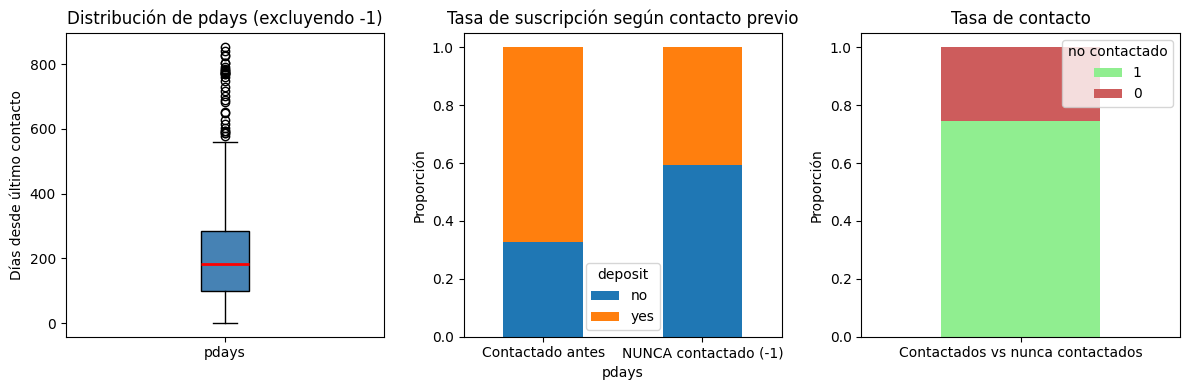

Correlación de la columna pdays con el target

0.15312052432102163

Correlación de la columna pdays (sólo para cuando no se le ha contactado)

-0.23190827436671366


In [35]:
print("ANÁLISIS ESPECÍFICO DE 'pdays'")

print(f"Valores únicos en pdays: {df['pdays'].nunique()}")
print(f"Valor -1 (nunca contactado): {(df['pdays'] == -1).sum()} instancias ({((df['pdays'] == -1).sum()/len(df))*100:.1f}%)")
print(f"Estadísticos excluyendo -1:")
pdays_positivos = df[df['pdays'] != -1]['pdays']
print(f"  - Min: {pdays_positivos.min()}")
print(f"  - Max: {pdays_positivos.max()}")
print(f"  - Media: {pdays_positivos.mean():.1f}")
print(f"  - Mediana: {pdays_positivos.median()}")

df_corr = df.copy()
df_corr['deposit'] = df_corr['deposit'].map({'yes': 1, 'no': 0})
df_corr['nunca_contactado'] = (df['pdays'] == -1).astype(int)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Boxplot de pdays (excluyendo -1) - REEMPLAZA AL HISTOGRAMA
axes[0].boxplot(pdays_positivos, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de pdays (excluyendo -1)')
axes[0].set_ylabel('Días desde último contacto')
axes[0].set_xticklabels(['pdays'])

# Relación con target (este se mantiene igual)
pd.crosstab(df['pdays'] == -1, df['deposit'], normalize='index').plot(
    kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Tasa de suscripción según contacto previo')
axes[1].set_xticklabels(['Contactado antes', 'NUNCA contactado (-1)'], rotation=0)
axes[1].set_ylabel('Proporción')
axes[1].legend(title='deposit')
print(df_corr['nunca_contactado'].value_counts())
df_corr['nunca_contactado'].value_counts(normalize=True).to_frame().T.plot(kind='bar', color=['lightgreen', 'indianred'], ax=axes[2], stacked=True)
axes[2].set_title('Tasa de contacto')
axes[2].set_ylabel('Proporción')
axes[2].set_xticklabels(['Contactados vs nunca contactados'], rotation=0)
axes[2].legend(title='no contactado')

plt.tight_layout()
plt.show()

print("Correlación de la columna pdays con el target\n")
target_corr = df_corr['deposit'].corr(df_corr['pdays'])
print(f"{target_corr}")

print("\nCorrelación de la columna pdays (sólo para cuando no se le ha contactado)\n")
target_corr = df_corr['deposit'].corr(df_corr['nunca_contactado'])
print(f"{target_corr}")

Como podemos ver, la variable pdays es irrelevante en comparación con la feature derivada nunca_contactado. Además al tener alta cardinalidad realentizará el proceso de entrenamiento de nuestros modelos, especialmente en el caso de los árboles, por lo que deberíamos eliminarlo.

## Preproceso
Con la eliminación de la columna pdays así como la creación de la nueva feature empezamos la etapa de preproceso.
para esto vamos a usar funciones para poder incluirlas en la pipeline final

# 

In [ ]:
def crear_nunca_contactado_eliminar_pdays(df):
    df_copy = df.copy()
    df_copy["nunca_contactado"] = (df_copy['pdays'] == -1).astype(int)
    df_copy = df_copy.drop('pdays', axis=1)
    return df_copy
preproceso_de_pdays = FunctionTransformer(crear_nunca_contactado_eliminar_pdays)
new_df = crear_nunca_contactado_eliminar_pdays(df)

KeyError: "['pdays'] not found in axis"